## LUT to NetworkX Graph Conversion

This project provides a Python script to convert Look-Up Tables (LUTs) into NetworkX graphs. The script reads LUT data from a .dot file and than coverts it into a graph structure that can be analyzed and visualized using NetworkX.

The objective of this project is to extract meaningful insights from LUTs by representing them as graphs, allowing for easier analysis and visualization of the relationships between different components in the LUT.

 * Author: Olavo Alves Barros Silva
 * Contact: olavo.barros@ufv.com
 * Date: 2026-04-30
 * License: [License Type]
 * Description: [Brief Description]



## Installation and Usage

## Libraries and Dependencies

In [96]:
# Graph related imports
import networkx as nx
from pyvis import  network as net


# Data manipulation
import numpy as np
import pandas as pd

# General utilities
import os
import sys
import json
import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

In [97]:
# Parameterized font sizes for easy adjustments
FONT_SIZE_BASE = 8
LABEL_SIZE = 8
TITLE_SIZE = 8
LEGEND_SIZE = 7
TICK_SIZE = 7

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "text.usetex": False,
    "svg.fonttype": "none",
    
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,

    "lines.linewidth": 1,
    "axes.grid": True,
    "grid.linewidth": 0.3,
    
    "figure.dpi": 300,
    "savefig.dpi": 300,
})



In [98]:
DATA_PATH = Path("../data")
RESULTS_PATH = Path("../../results")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

GRAPH_NAME = "result"
JSON_FILE = DATA_PATH / f"{GRAPH_NAME}.json"



## Visualization Functions

In [99]:
def graph_visualization(graph):
  """Graph visualization using Pyvis

  Args:
      graph (networkx.direct): A direct oriented graph to be visualized
  """

  # Create the folder RESULTS_PATH/GRAPH_NAME/vis if it does not exist
  vis_path = RESULTS_PATH / GRAPH_NAME / "vis"
  vis_path.mkdir(parents=True, exist_ok=True)

  nt = net.Network(notebook = True, directed=True)
  nt.from_nx(graph)
  nt.save_graph('digraph_visualization.html')
  

## Graph Construction Functions

In [104]:
def build_graph_from_yosys(json_path):
    """
    Build a directed graph from a Yosys .json file.

    Args:
        json_path (PATH): Path to .json file with the description of the LUT graph

    Returns:
        nx.DiGraph: The networkx graph that represents the LUT graph
    """
    with open(json_path, 'r') as f:
        design = json.load(f)

    # Extract the top module (e.g., TreeLUT)
    module_name = list(design['modules'].keys())[0]
    cells = design['modules'][module_name].get('cells', {})
    ports = design['modules'][module_name].get('ports', {})

    G = nx.DiGraph()

    # 1. Register nodes for inputs, outputs, and cells
    for port_name, port_data in ports.items():
        direction = port_data.get('direction')
        if direction == 'input':
            for bit in port_data.get('bits', []):
                G.add_node(bit,
                           type='input',
                           tag=port_name,
                           color='blue',
                           label=f"I_{bit}")
        elif direction == 'output':
            for bit in port_data.get('bits', []):
                G.add_node(f'{port_name}_{bit}',
                           type='output',
                           tag=port_name,
                           color='red',
                           label=f"O_{port_name}_{bit}")

    for cell_name, cell_data in cells.items():
        if cell_data.get('type') == '$lut':
            node_name = cell_data.get('connections', {}).get('Y', [cell_name])[0]
            G.add_node(node_name,
                       type=cell_data.get('type', '$lut'),
                       tag=cell_name,
                       metadata=cell_data,
                       color='green',
                       label=f"L_{node_name}")

    # 2. Create edges based on connections
    # Build a reverse map: bit ID -> node name in G (for LUT outputs and input ports)
    # Input port nodes are already keyed by their bit ID.
    # LUT nodes are keyed by their Y output bit ID.
    # Output port nodes are keyed as '{port_name}_{bit}', but their bit is
    # consumed as a *destination*, not a source, so we handle them separately.

    # Map each output bit ID to the corresponding output port node name
    output_bit_to_node = {}
    for port_name, port_data in ports.items():
        if port_data.get('direction') == 'output':
            for bit in port_data.get('bits', []):
                output_bit_to_node[bit] = f'{port_name}_{bit}'

    for node, node_data in G.nodes(data=True):
        if node_data['type'] == '$lut':
            cell_data = node_data['metadata']
            connections = cell_data.get('connections', {})

            for port, bits in connections.items():
                if port == 'A':
                    # Each bit in A is an input to this LUT node.
                    # The source is whichever node in G owns that bit ID.
                    for bit in bits:
                        if G.has_node(bit):
                            # Source is an input port node or another LUT's output
                            G.add_edge(bit, node)
                        # If the bit isn't a known node it's an undriven/constant
                        # wire — skip it silently.

                elif port == 'Y':
                    # The output bit may feed into an output port node.
                    for bit in bits:
                        if bit in output_bit_to_node:
                            G.add_edge(node, output_bit_to_node[bit])

    return G
    

def get_edge_strength(graph, edge):
    """Get the strength of an edge based on the types of the connected nodes.

    Args:
        graph (networkx.DiGraph): The graph containing the edge.
        edge (tuple): A tuple representing the edge (source, target).

    Returns:
        int: The strength of the edge. 2 for LUT-to-LUT, 1 for LUT-to-FF or FF-to-LUT, and 0 for FF-to-FF.
    """
    source, target = edge
    source_type = graph.nodes[source].get('type', 'unknown')
    target_type = graph.nodes[target].get('type', 'unknown')
    
    if source_type == 'LUT' and target_type == 'LUT':
        return 2
    elif (source_type == 'LUT' and target_type == 'FF') or (source_type == 'FF' and target_type == 'LUT'):
        return 1
    elif source_type == 'FF' and target_type == 'FF':
        return 0
    else:
        return -1  # Unknown types

Graph constructed with 2674 nodes and 4646 edges.
Node type distribution:
  input: 1648
  output: 4
  $lut: 1022

Node degree statistics:
  input: avg in-degree = 0.00, avg out-degree = 0.73
  output: avg in-degree = 1.00, avg out-degree = 0.00
  $lut: avg in-degree = 4.54, avg out-degree = 3.37


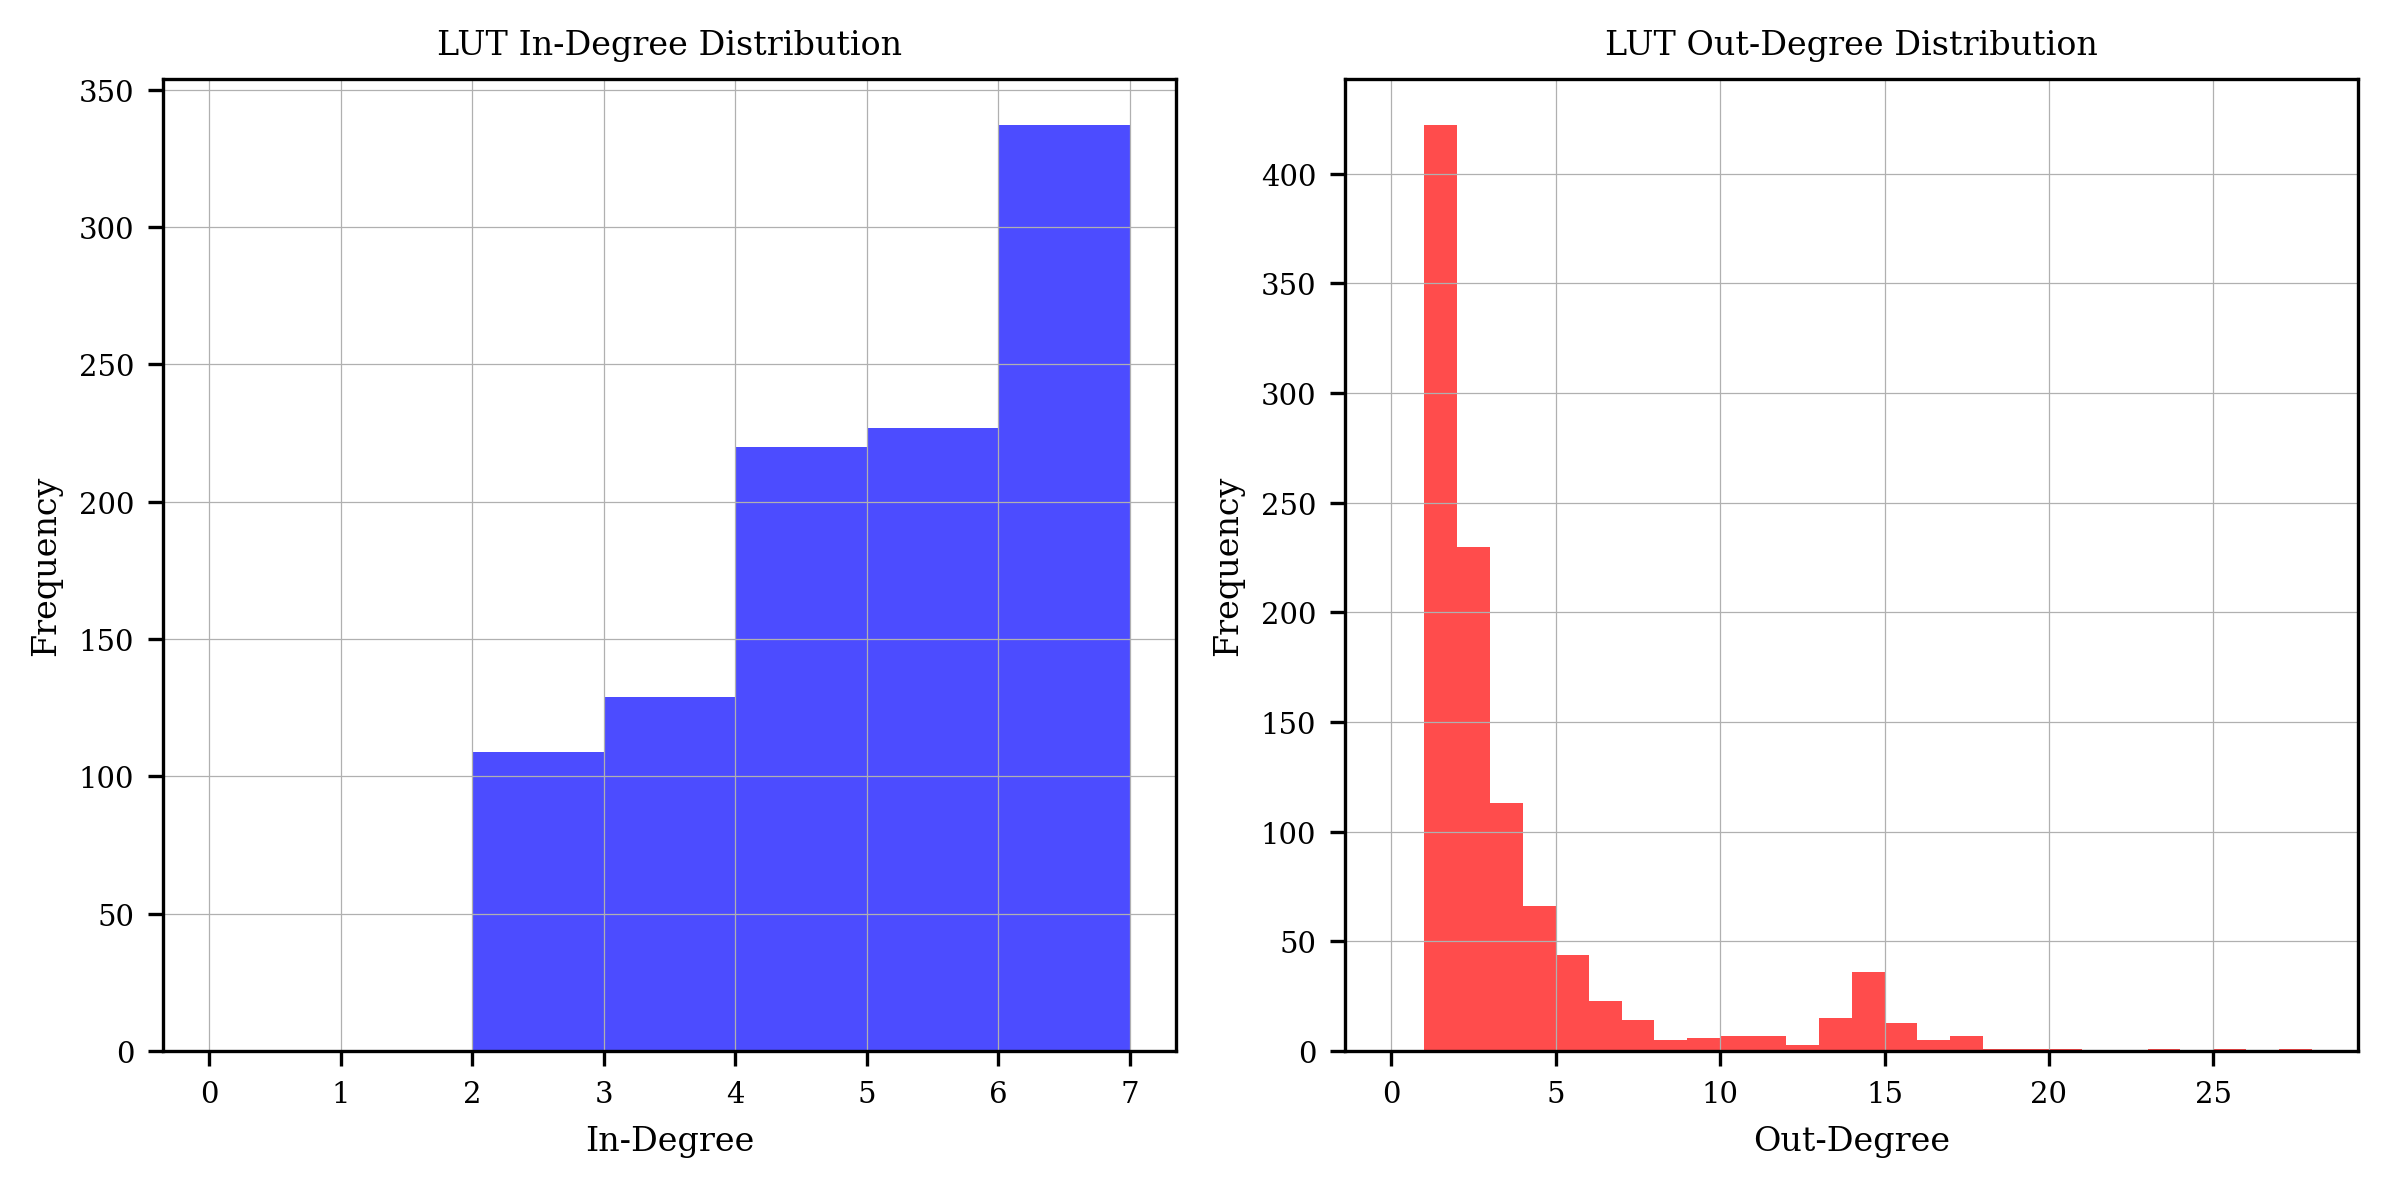

In [109]:
# Execute the pipeline
G = build_graph_from_yosys(JSON_FILE)

print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Get node statistics
node_types = {}
for node, data in G.nodes(data=True):
    node_type = data.get('type', 'unknown')
    node_types[node_type] = node_types.get(node_type, 0) + 1
print("Node type distribution:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

# Node degrees per type and per input/output degree
degree_stats = {}
for node, data in G.nodes(data=True):
    node_type = data.get('type', 'unknown')
    in_degree = G.in_degree(node)
    out_degree = G.out_degree(node)
    
    if node_type not in degree_stats:
        degree_stats[node_type] = {
            'in_degree': [],
            'out_degree': []
        }
    
    degree_stats[node_type]['in_degree'].append(in_degree)
    degree_stats[node_type]['out_degree'].append(out_degree)
print("\nNode degree statistics:")
for node_type, stats in degree_stats.items():
    avg_in = np.mean(stats['in_degree'])
    avg_out = np.mean(stats['out_degree'])
    print(f"  {node_type}: avg in-degree = {avg_in:.2f}, avg out-degree = {avg_out:.2f}")

# Plot degree distribution for LUT nodes
lut_in_degrees = degree_stats.get('$lut', {}).get('in_degree', [])
lut_out_degrees = degree_stats.get('$lut', {}).get('out_degree', [])
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(lut_in_degrees, bins=range(max(lut_in_degrees)+2
), alpha=0.7, color='blue')
plt.title('LUT In-Degree Distribution')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(lut_out_degrees, bins=range(max(lut_out_degrees)+2), alpha=0.7, color='red')
plt.title('LUT Out-Degree Distribution')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(RESULTS_PATH / GRAPH_NAME / "lut_degree_distribution.png")
plt.show()

